# Scikit-learn Pipeline Tutorial
## Unsupervised Clustering with the PENGUINS Dataset
## IGNORE INFO ABOUT IRIS Dataset

This notebook walks through building a **scikit-learn `Pipeline`** for unsupervised clustering. Pipelines are one of the most useful patterns in scikit-learn — they chain preprocessing and modelling steps into a single, reusable object that prevents data leakage and keeps your code clean.

We'll use the classic **Iris dataset** (150 samples of iris flowers, 4 numeric features, 1 categorical species label) and apply **K-Means clustering** to rediscover the three species purely from the raw measurements.

## 1. Imports

We pull in everything we need up front:

| Import | Purpose |
|--------|----------|
| `Pipeline` | Chains steps sequentially |
| `ColumnTransformer` | Applies different transformers to different column subsets |
| `StandardScaler` | Scales numeric features to zero mean, unit variance |
| `OneHotEncoder` | Encodes categorical features as binary columns |
| `SimpleImputer` | Fills in missing values |
| `KMeans` | Partitions data into *k* clusters |

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

## 2. Load the Dataset

The **Iris dataset** contains measurements for 150 iris flowers across three species (*setosa*, *versicolor*, *virginica*).

- **4 numeric features**: sepal length, sepal width, petal length, petal width (all in cm)
- **1 categorical feature**: `species` (the true label — we'll ignore this during clustering, but use it later to evaluate)

> **Note:** In unsupervised learning there is no separate target column to drop. We feed the entire feature matrix `X` into the pipeline — including the categorical `species` column — to let the pipeline handle all preprocessing.

In [2]:
guins = sns.load_dataset("penguins")
print(f"Shape: {guins.shape}")
guins.head()

Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
guins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## 3. Identify Numeric and Categorical Columns

We automatically detect column types using pandas `select_dtypes`. This approach is robust — if the dataset gains or loses columns later, the code adapts without manual changes.

- **Numeric columns** → will be imputed (median) then scaled
- **Categorical columns** → will be imputed (most frequent) then one-hot encoded

In [4]:
X = guins.copy().drop(columns=["species"])

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:    ", numeric_features)
print("Categorical features:", categorical_features)

Numeric features:     ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']


## 4. Build the Preprocessing Sub-Pipelines

Each column type gets its own mini-pipeline. Wrapping imputation and transformation together ensures the imputer is fit only on training data — critical for avoiding data leakage in supervised settings, and good practice here too.

### 4a. Numeric transformer
1. **`SimpleImputer(strategy="median")`** — fills `NaN`s with the column median. The median is more robust to outliers than the mean.
2. **`StandardScaler()`** — subtracts the mean and divides by standard deviation. K-Means uses Euclidean distance, so unscaled features with larger ranges would dominate the distance calculation.

### 4b. Categorical transformer
1. **`SimpleImputer(strategy="most_frequent")`** — fills `NaN`s with the most common category.
2. **`OneHotEncoder(handle_unknown="ignore")`** — converts each category level into a binary column. `handle_unknown="ignore"` means unseen categories at inference time produce all-zeros rather than raising an error.

In [5]:
# Numeric sub-pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Categorical sub-pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore"))
])

## 5. Combine with ColumnTransformer

`ColumnTransformer` is the glue that routes each column subset to the right sub-pipeline and then **concatenates** the outputs into a single transformed matrix.

Each entry is a tuple of `(name, transformer, columns)`:
```
("num", numeric_transformer, numeric_features)
("cat", categorical_transformer, categorical_features)
```

The resulting array has the scaled numeric columns on the left and the one-hot columns on the right.

In [6]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,    numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## 6. Build the Full Pipeline

Now we attach the clustering model as the final step. The complete pipeline is:

```
Raw DataFrame
     │
     ▼
ColumnTransformer  ← numeric: impute → scale
                   ← categorical: impute → one-hot
     │
     ▼
KMeans(n_clusters=3)
     │
     ▼
Cluster labels [0, 1, 2, ...]
```

We choose `n_clusters=3` because we know there are three iris species. In practice you'd use the **elbow method** or **silhouette scores** to pick this value.

In [8]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("cluster",    KMeans(n_clusters=10, random_state=42, n_init="auto"))
])

# Inspect the pipeline structure
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('cluster', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 7. Fit the Pipeline

Calling `pipeline.fit(X)` runs each step in sequence:
1. The `ColumnTransformer` fits its imputers and scalers on `X`, then transforms it.
2. `KMeans` receives the transformed matrix and learns the cluster centroids.

Because this is **unsupervised**, we pass only `X` (no labels `y`).

In [8]:
pipeline.fit(X)
print("Pipeline fitted successfully.")

Pipeline fitted successfully.


C:\Users\biauser\anaconda3\envs\ds312\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


## 8. Extract Cluster Labels

After fitting, `pipeline["cluster"].labels_` holds the integer cluster assignment for every row. We attach these back to the original DataFrame for easy analysis.

> **Tip:** Cluster labels are arbitrary integers. Cluster `0` doesn't necessarily correspond to *setosa* — the mapping may differ each run unless `random_state` is fixed.

In [9]:
cluster_labels = pipeline["cluster"].labels_

guins_with_clusters = guins.copy()
guins_with_clusters["cluster"] = cluster_labels

print(guins_with_clusters.head(10))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   
8  Adelie  Torgersen            34.1           18.1              193.0   
9  Adelie  Torgersen            42.0           20.2              190.0   

   body_mass_g     sex  cluster  
0       3750.0    Male        2  
1       3800.0  Female        0  
2       3250.0  Female        0  
3          NaN     NaN        2  
4       3450.0 

## 9. Evaluate: Clusters vs True Species

Since Iris has ground-truth labels, we can compare the discovered clusters against the real species. A crosstab shows how well K-Means separated the three classes.

In [10]:
ct = pd.crosstab(
    guins_with_clusters["species"],
    guins_with_clusters["cluster"],
    rownames=["True species"],
    colnames=["Cluster"]
)
print(ct)

Cluster        0    1   2
True species             
Adelie        81    0  71
Chinstrap     22    0  46
Gentoo         0  123   1


## 10. Visualise the Clusters

We'll plot **petal length vs petal width** — the two features that best separate the species — coloured by cluster assignment. Marker shape encodes the true species for comparison.

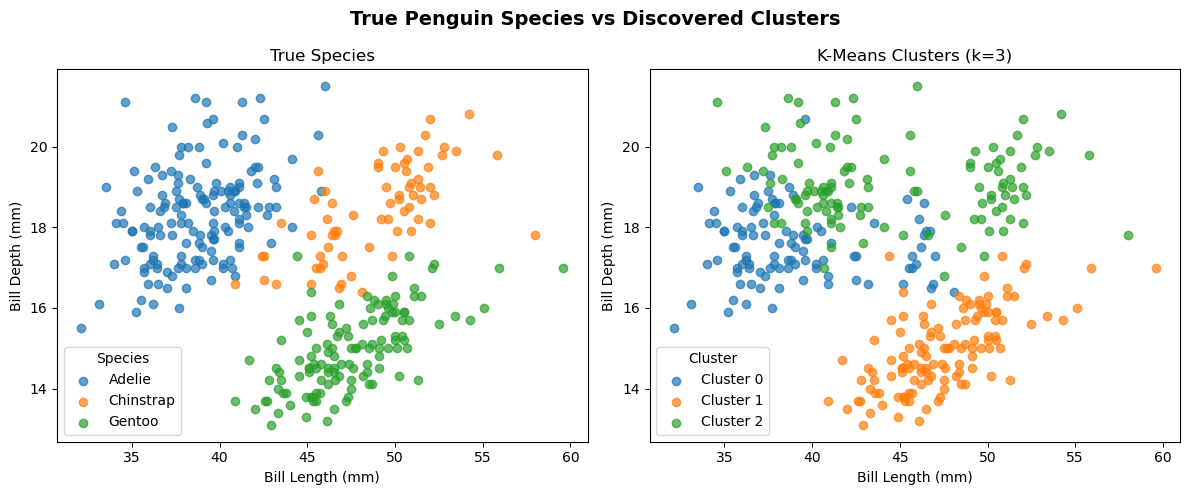

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: true species
for sp, grp in guins_with_clusters.groupby("species"):
    axes[0].scatter(
        grp["bill_length_mm"],
        grp["bill_depth_mm"],
        label=sp,
        alpha=0.7
    )

axes[0].set_title("True Species")
axes[0].set_xlabel("Bill Length (mm)")
axes[0].set_ylabel("Bill Depth (mm)")
axes[0].legend(title="Species")


# Right: K-Means clusters
for cl, grp in guins_with_clusters.groupby("cluster"):
    axes[1].scatter(
        grp["bill_length_mm"],
        grp["bill_depth_mm"],
        label=f"Cluster {cl}",
        alpha=0.7
    )

axes[1].set_title("K-Means Clusters (k=3)")
axes[1].set_xlabel("Bill Length (mm)")
axes[1].set_ylabel("Bill Depth (mm)")
axes[1].legend(title="Cluster")


plt.suptitle(
    "True Penguin Species vs Discovered Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


## 11. Predict on New Data

One of the great advantages of a `Pipeline` is that `predict()` (or `fit_predict()`) automatically applies **all preprocessing steps** before inference. You never have to manually scale new samples.

Here we pass two hypothetical new flowers and get their cluster assignments.

In [15]:
new_penguins = pd.DataFrame({
    "bill_length_mm":    [39.1, 50.4],
    "bill_depth_mm":     [18.7, 15.3],
    "flipper_length_mm": [181, 220],
    "body_mass_g":       [3750, 5000],
    "island":            ["Torgersen", "Biscoe"],
    "sex":               ["Male", "Female"]
})

predictions = pipeline.predict(new_penguins)
new_penguins["predicted_cluster"] = predictions
print(new_penguins)

   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     island  \
0            39.1           18.7                181         3750  Torgersen   
1            50.4           15.3                220         5000     Biscoe   

      sex  predicted_cluster  
0    Male                  2  
1  Female                  1  


## Summary

Here's what we built:

```
Pipeline
├── preprocess: ColumnTransformer
│   ├── num: Pipeline
│   │   ├── SimpleImputer(strategy='median')
│   │   └── StandardScaler()
│   └── cat: Pipeline
│       ├── SimpleImputer(strategy='most_frequent')
│       └── OneHotEncoder(handle_unknown='ignore')
└── cluster: KMeans(n_clusters=3)
```

**Key takeaways:**
- `Pipeline` chains steps and prevents data leakage by fitting transformers only on training data.
- `ColumnTransformer` handles mixed-type DataFrames by routing columns to the appropriate transformer.
- The full pipeline exposes `.fit()`, `.predict()`, and `.fit_predict()` — preprocessing is invisible to the caller.
- K-Means recovers the three iris species remarkably well from raw measurements alone, though *versicolor* and *virginica* overlap slightly.